# 第十四章：Bahdanau 注意力機制

## Neural Machine Translation by Jointly Learning to Align and Translate
## Bahdanau, Cho, Bengio (2014)

這篇論文首創了「注意力機制」，讓解碼器能動態關注輸入序列的不同部分，解決了固定向量編碼的資訊瓶頸問題。

**核心貢獻**：
- 加性注意力（Additive Attention）
- 雙向編碼器
- 動態上下文向量
- 對齊的可視化

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 檢查裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

使用裝置：cpu


## 1. 問題：固定向量的資訊瓶頸

傳統 Seq2Seq 將整個輸入壓縮成單一向量，造成資訊損失。

```
輸入: x₁ → x₂ → x₃ → x₄ → [固定向量 c]
                              ↓
輸出:                    c → y₁ → y₂ → y₃
```

**問題**：無論輸入多長，都被壓縮到相同大小的向量。

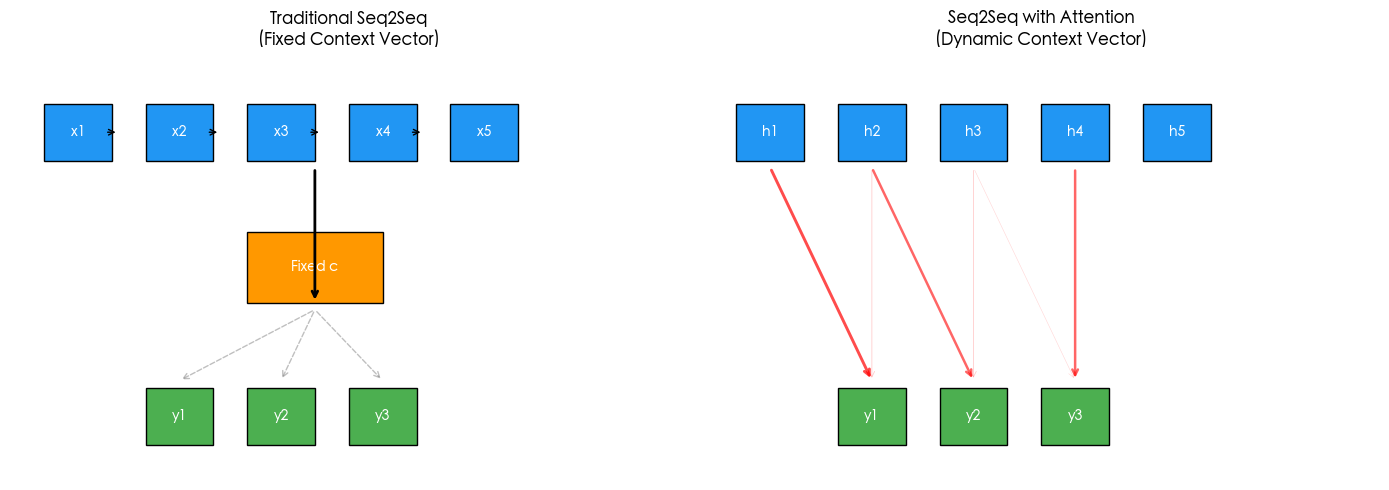

圖片已儲存：attention_vs_fixed.png

傳統 Seq2Seq：所有解碼步驟使用相同的固定向量
帶注意力：每個解碼步驟動態選擇關注的位置


In [2]:
# 視覺化資訊瓶頸問題
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：傳統 Seq2Seq（固定向量）
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title('Traditional Seq2Seq\n(Fixed Context Vector)', fontsize=12, fontweight='bold')

# 編碼器輸入
for i in range(5):
    ax1.add_patch(plt.Rectangle((i*1.5+0.5, 4.5), 1, 0.8, facecolor='#2196F3', edgecolor='black'))
    ax1.text(i*1.5+1, 4.9, f'x{i+1}', ha='center', va='center', fontsize=10, color='white')
    if i < 4:
        ax1.annotate('', xy=(i*1.5+1.6, 4.9), xytext=(i*1.5+1.4, 4.9),
                    arrowprops=dict(arrowstyle='->', color='black'))

# 固定向量
ax1.add_patch(plt.Rectangle((3.5, 2.5), 2, 1, facecolor='#FF9800', edgecolor='black'))
ax1.text(4.5, 3, 'Fixed c', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax1.annotate('', xy=(4.5, 2.5), xytext=(4.5, 4.4),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# 解碼器輸出
for i in range(3):
    ax1.add_patch(plt.Rectangle((i*1.5+2, 0.5), 1, 0.8, facecolor='#4CAF50', edgecolor='black'))
    ax1.text(i*1.5+2.5, 0.9, f'y{i+1}', ha='center', va='center', fontsize=10, color='white')
    ax1.annotate('', xy=(i*1.5+2.5, 1.4), xytext=(4.5, 2.4),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, ls='--'))

# 右圖：帶注意力的 Seq2Seq
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title('Seq2Seq with Attention\n(Dynamic Context Vector)', fontsize=12, fontweight='bold')

# 編碼器輸入
colors_enc = ['#2196F3', '#2196F3', '#2196F3', '#2196F3', '#2196F3']
for i in range(5):
    ax2.add_patch(plt.Rectangle((i*1.5+0.5, 4.5), 1, 0.8, facecolor=colors_enc[i], edgecolor='black'))
    ax2.text(i*1.5+1, 4.9, f'h{i+1}', ha='center', va='center', fontsize=10, color='white')

# 注意力連接
alphas = [[0.7, 0.2, 0.05, 0.03, 0.02],  # y1 的注意力
          [0.1, 0.6, 0.2, 0.05, 0.05],   # y2 的注意力
          [0.05, 0.1, 0.15, 0.6, 0.1]]   # y3 的注意力

for j in range(3):  # 每個輸出
    for i in range(5):  # 每個輸入
        alpha = alphas[j][i]
        if alpha > 0.1:
            ax2.annotate('', xy=(j*1.5+2.5, 1.4), xytext=(i*1.5+1, 4.4),
                        arrowprops=dict(arrowstyle='->', color='red', alpha=alpha, lw=alpha*3))

# 解碼器輸出
for i in range(3):
    ax2.add_patch(plt.Rectangle((i*1.5+2, 0.5), 1, 0.8, facecolor='#4CAF50', edgecolor='black'))
    ax2.text(i*1.5+2.5, 0.9, f'y{i+1}', ha='center', va='center', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('attention_vs_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：attention_vs_fixed.png")
print("\n傳統 Seq2Seq：所有解碼步驟使用相同的固定向量")
print("帶注意力：每個解碼步驟動態選擇關注的位置")

## 2. Bahdanau 注意力機制

### 核心公式

**注意力分數（對齊模型）**：
$$e_{ij} = v_a^T \tanh(W_a s_{i-1} + U_a h_j)$$

**注意力權重**：
$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})}$$

**上下文向量**：
$$c_i = \sum_{j=1}^{T_x} \alpha_{ij} h_j$$

In [3]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau 加性注意力機制
    
    使用前饋網路計算注意力分數：
    e_ij = v^T tanh(W * s + U * h)
    """
    
    def __init__(self, hidden_size, annotation_size):
        """
        Args:
            hidden_size: 解碼器隱藏狀態維度
            annotation_size: 編碼器註解維度（雙向 RNN 時為 2 * hidden_size）
        """
        super().__init__()
        
        # 注意力參數
        self.W_a = nn.Linear(hidden_size, hidden_size, bias=False)  # 投影解碼器狀態
        self.U_a = nn.Linear(annotation_size, hidden_size, bias=False)  # 投影編碼器註解
        self.v_a = nn.Linear(hidden_size, 1, bias=False)  # 計算純量分數
    
    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        """
        Args:
            decoder_hidden: [batch, hidden_size] 解碼器的前一步隱藏狀態
            encoder_outputs: [batch, src_len, annotation_size] 編碼器的所有輸出
            mask: [batch, src_len] 可選的填充遮罩
        
        Returns:
            context: [batch, annotation_size] 加權上下文向量
            attention_weights: [batch, src_len] 注意力權重
        """
        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]
        
        # 投影解碼器狀態：[batch, hidden] -> [batch, 1, hidden]
        decoder_proj = self.W_a(decoder_hidden).unsqueeze(1)
        
        # 投影編碼器輸出：[batch, src_len, annotation] -> [batch, src_len, hidden]
        encoder_proj = self.U_a(encoder_outputs)
        
        # 計算注意力分數：e_ij = v^T tanh(W*s + U*h)
        # [batch, src_len, hidden] -> [batch, src_len, 1] -> [batch, src_len]
        scores = self.v_a(torch.tanh(decoder_proj + encoder_proj)).squeeze(-1)
        
        # 套用遮罩（如果有）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Softmax 得到注意力權重
        attention_weights = F.softmax(scores, dim=-1)
        
        # 計算上下文向量：c = sum(alpha * h)
        # [batch, 1, src_len] @ [batch, src_len, annotation] -> [batch, 1, annotation]
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        
        return context, attention_weights

# 測試注意力機制
hidden_size = 32
annotation_size = 64  # 雙向 RNN，所以是 2 * hidden_size
batch_size = 2
src_len = 8

attention = BahdanauAttention(hidden_size, annotation_size)

# 模擬輸入
decoder_hidden = torch.randn(batch_size, hidden_size)
encoder_outputs = torch.randn(batch_size, src_len, annotation_size)

context, weights = attention(decoder_hidden, encoder_outputs)

print("Bahdanau 注意力測試：")
print(f"  解碼器狀態形狀: {decoder_hidden.shape}")
print(f"  編碼器輸出形狀: {encoder_outputs.shape}")
print(f"  上下文向量形狀: {context.shape}")
print(f"  注意力權重形狀: {weights.shape}")
print(f"  注意力權重和: {weights[0].sum().item():.4f}（應為 1.0）")

Bahdanau 注意力測試：
  解碼器狀態形狀: torch.Size([2, 32])
  編碼器輸出形狀: torch.Size([2, 8, 64])
  上下文向量形狀: torch.Size([2, 64])
  注意力權重形狀: torch.Size([2, 8])
  注意力權重和: 1.0000（應為 1.0）


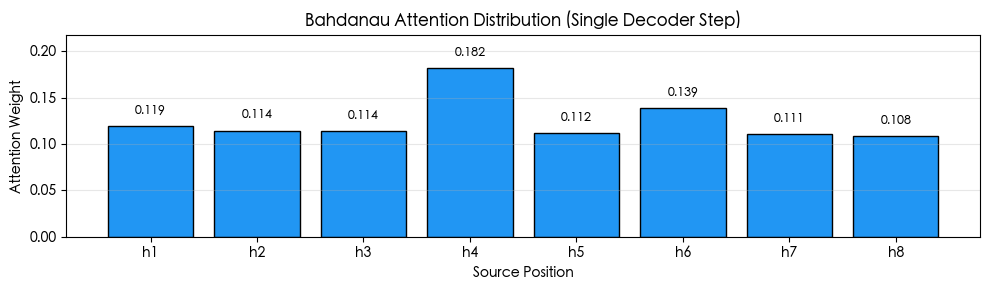

圖片已儲存：bahdanau_attention_weights.png


In [4]:
# 視覺化注意力權重
fig, ax = plt.subplots(figsize=(10, 3))

weights_np = weights[0].detach().numpy()
bars = ax.bar(range(src_len), weights_np, color='#2196F3', edgecolor='black')

# 標註數值
for i, (bar, w) in enumerate(zip(bars, weights_np)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{w:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Source Position')
ax.set_ylabel('Attention Weight')
ax.set_title('Bahdanau Attention Distribution (Single Decoder Step)')
ax.set_xticks(range(src_len))
ax.set_xticklabels([f'h{i+1}' for i in range(src_len)])
ax.set_ylim(0, max(weights_np) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('bahdanau_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：bahdanau_attention_weights.png")

## 3. 雙向編碼器

Bahdanau 使用雙向 GRU 來獲得更豐富的表示：

$$\overrightarrow{h_j} = \text{GRU}(x_j, \overrightarrow{h_{j-1}})$$
$$\overleftarrow{h_j} = \text{GRU}(x_j, \overleftarrow{h_{j+1}})$$
$$h_j = [\overrightarrow{h_j}; \overleftarrow{h_j}]$$

In [5]:
class BidirectionalEncoder(nn.Module):
    """
    雙向 GRU 編碼器
    
    產生包含前後文資訊的註解序列
    """
    
    def __init__(self, vocab_size, embed_size, hidden_size, dropout=0.1):
        """
        Args:
            vocab_size: 詞彙表大小
            embed_size: 詞嵌入維度
            hidden_size: GRU 隱藏層維度（單向）
            dropout: Dropout 比例
        """
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        
        self.hidden_size = hidden_size
    
    def forward(self, src, src_lengths=None):
        """
        Args:
            src: [batch, src_len] 來源序列的 token 索引
            src_lengths: [batch] 每個序列的實際長度
        
        Returns:
            outputs: [batch, src_len, 2*hidden_size] 雙向編碼器輸出
            hidden: [batch, 2*hidden_size] 最終隱藏狀態
        """
        # 詞嵌入
        embedded = self.dropout(self.embedding(src))  # [batch, src_len, embed_size]
        
        # 雙向 GRU
        outputs, hidden = self.gru(embedded)  # outputs: [batch, src_len, 2*hidden]
        
        # hidden: [2, batch, hidden] -> [batch, 2*hidden]
        # 拼接前向和後向的最終狀態
        hidden = torch.cat([hidden[0], hidden[1]], dim=-1)
        
        return outputs, hidden

# 測試編碼器
vocab_size = 1000
embed_size = 64
hidden_size = 32
batch_size = 2
src_len = 10

encoder = BidirectionalEncoder(vocab_size, embed_size, hidden_size)

# 隨機輸入
src = torch.randint(0, vocab_size, (batch_size, src_len))

outputs, hidden = encoder(src)

print("雙向編碼器測試：")
print(f"  輸入形狀: {src.shape}")
print(f"  輸出（註解）形狀: {outputs.shape}")
print(f"  隱藏狀態形狀: {hidden.shape}")
print(f"\n每個位置的註解維度是隱藏維度的 2 倍（前向 + 後向）")

雙向編碼器測試：
  輸入形狀: torch.Size([2, 10])
  輸出（註解）形狀: torch.Size([2, 10, 64])
  隱藏狀態形狀: torch.Size([2, 64])

每個位置的註解維度是隱藏維度的 2 倍（前向 + 後向）


## 4. 帶注意力的解碼器

解碼器在每一步：
1. 用前一步狀態計算注意力
2. 獲得動態上下文向量
3. 結合上下文生成輸出

In [6]:
class AttentionDecoder(nn.Module):
    """
    帶 Bahdanau 注意力的 GRU 解碼器
    """
    
    def __init__(self, vocab_size, embed_size, hidden_size, annotation_size, dropout=0.1):
        """
        Args:
            vocab_size: 目標詞彙表大小
            embed_size: 詞嵌入維度
            hidden_size: GRU 隱藏層維度
            annotation_size: 編碼器註解維度
            dropout: Dropout 比例
        """
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        
        # 詞嵌入
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # 注意力機制
        self.attention = BahdanauAttention(hidden_size, annotation_size)
        
        # GRU：輸入是 [嵌入 + 上下文]
        self.gru = nn.GRU(embed_size + annotation_size, hidden_size, batch_first=True)
        
        # 輸出層：[隱藏狀態 + 上下文 + 嵌入] -> 詞彙表
        self.output_layer = nn.Linear(hidden_size + annotation_size + embed_size, vocab_size)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward_step(self, prev_token, prev_hidden, encoder_outputs, mask=None):
        """
        單步解碼
        
        Args:
            prev_token: [batch] 前一個 token
            prev_hidden: [batch, hidden_size] 前一步隱藏狀態
            encoder_outputs: [batch, src_len, annotation_size] 編碼器輸出
            mask: 填充遮罩
        
        Returns:
            output: [batch, vocab_size] 輸出 logits
            hidden: [batch, hidden_size] 新隱藏狀態
            attention_weights: [batch, src_len] 注意力權重
        """
        # 詞嵌入
        embedded = self.dropout(self.embedding(prev_token))  # [batch, embed_size]
        
        # 計算注意力和上下文
        context, attention_weights = self.attention(prev_hidden, encoder_outputs, mask)
        
        # GRU 輸入：[嵌入, 上下文]
        gru_input = torch.cat([embedded, context], dim=-1).unsqueeze(1)  # [batch, 1, embed+annot]
        
        # GRU
        _, hidden = self.gru(gru_input, prev_hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)  # [batch, hidden]
        
        # 輸出：[隱藏狀態, 上下文, 嵌入]
        output_input = torch.cat([hidden, context, embedded], dim=-1)
        output = self.output_layer(output_input)  # [batch, vocab_size]
        
        return output, hidden, attention_weights
    
    def forward(self, encoder_outputs, encoder_hidden, target=None, max_len=50, mask=None):
        """
        完整解碼（訓練時用教師強制）
        
        Args:
            encoder_outputs: [batch, src_len, annotation_size]
            encoder_hidden: [batch, annotation_size] 用於初始化解碼器
            target: [batch, tgt_len] 目標序列（訓練時）
            max_len: 最大生成長度（推論時）
            mask: 填充遮罩
        """
        batch_size = encoder_outputs.shape[0]
        
        # 初始化解碼器隱藏狀態（從編碼器狀態投影）
        hidden = torch.tanh(nn.Linear(encoder_hidden.shape[-1], self.hidden_size)
                           .to(encoder_hidden.device)(encoder_hidden))
        
        # 決定解碼長度
        if target is not None:
            max_len = target.shape[1]
            use_teacher_forcing = True
        else:
            use_teacher_forcing = False
        
        # 初始 token（假設 0 是 <SOS>）
        prev_token = torch.zeros(batch_size, dtype=torch.long, device=encoder_outputs.device)
        
        outputs = []
        attention_history = []
        
        for t in range(max_len):
            output, hidden, attention_weights = self.forward_step(
                prev_token, hidden, encoder_outputs, mask
            )
            
            outputs.append(output)
            attention_history.append(attention_weights)
            
            # 下一步輸入
            if use_teacher_forcing:
                prev_token = target[:, t]
            else:
                prev_token = output.argmax(dim=-1)
        
        outputs = torch.stack(outputs, dim=1)  # [batch, tgt_len, vocab_size]
        attention_history = torch.stack(attention_history, dim=1)  # [batch, tgt_len, src_len]
        
        return outputs, attention_history

# 測試解碼器
tgt_vocab_size = 1000
embed_size = 64
hidden_size = 32
annotation_size = 64  # 2 * encoder_hidden_size

decoder = AttentionDecoder(tgt_vocab_size, embed_size, hidden_size, annotation_size)

# 模擬輸入
batch_size = 2
src_len = 10
tgt_len = 8

encoder_outputs = torch.randn(batch_size, src_len, annotation_size)
encoder_hidden = torch.randn(batch_size, annotation_size)
target = torch.randint(0, tgt_vocab_size, (batch_size, tgt_len))

outputs, attention_history = decoder(encoder_outputs, encoder_hidden, target)

print("注意力解碼器測試：")
print(f"  編碼器輸出形狀: {encoder_outputs.shape}")
print(f"  目標序列形狀: {target.shape}")
print(f"  解碼器輸出形狀: {outputs.shape}")
print(f"  注意力歷史形狀: {attention_history.shape}")

注意力解碼器測試：
  編碼器輸出形狀: torch.Size([2, 10, 64])
  目標序列形狀: torch.Size([2, 8])
  解碼器輸出形狀: torch.Size([2, 8, 1000])
  注意力歷史形狀: torch.Size([2, 8, 10])


## 5. 對齊矩陣視覺化

注意力權重形成的矩陣展示了來源和目標的對齊關係

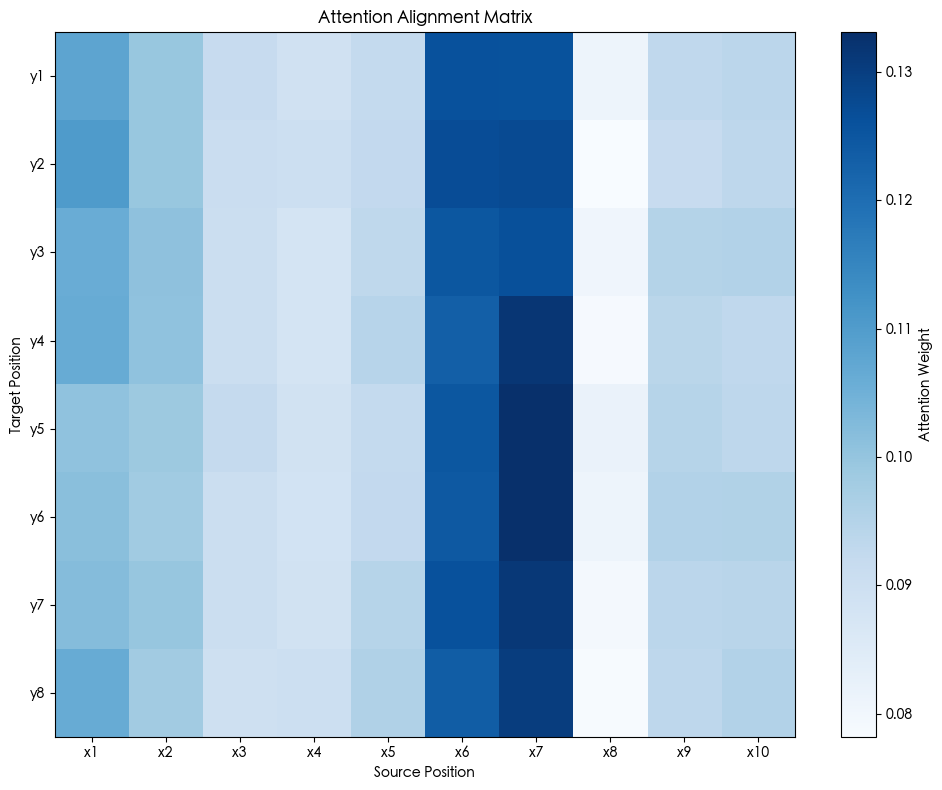

圖片已儲存：alignment_matrix.png

對齊矩陣展示了翻譯每個目標詞時關注的來源位置


In [7]:
# 視覺化注意力對齊矩陣
attention_matrix = attention_history[0].detach().numpy()  # [tgt_len, src_len]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')
plt.colorbar(im, label='Attention Weight')

ax.set_xlabel('Source Position')
ax.set_ylabel('Target Position')
ax.set_title('Attention Alignment Matrix')

# 標籤
ax.set_xticks(range(src_len))
ax.set_xticklabels([f'x{i+1}' for i in range(src_len)])
ax.set_yticks(range(tgt_len))
ax.set_yticklabels([f'y{i+1}' for i in range(tgt_len)])

plt.tight_layout()
plt.savefig('alignment_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：alignment_matrix.png")
print("\n對齊矩陣展示了翻譯每個目標詞時關注的來源位置")

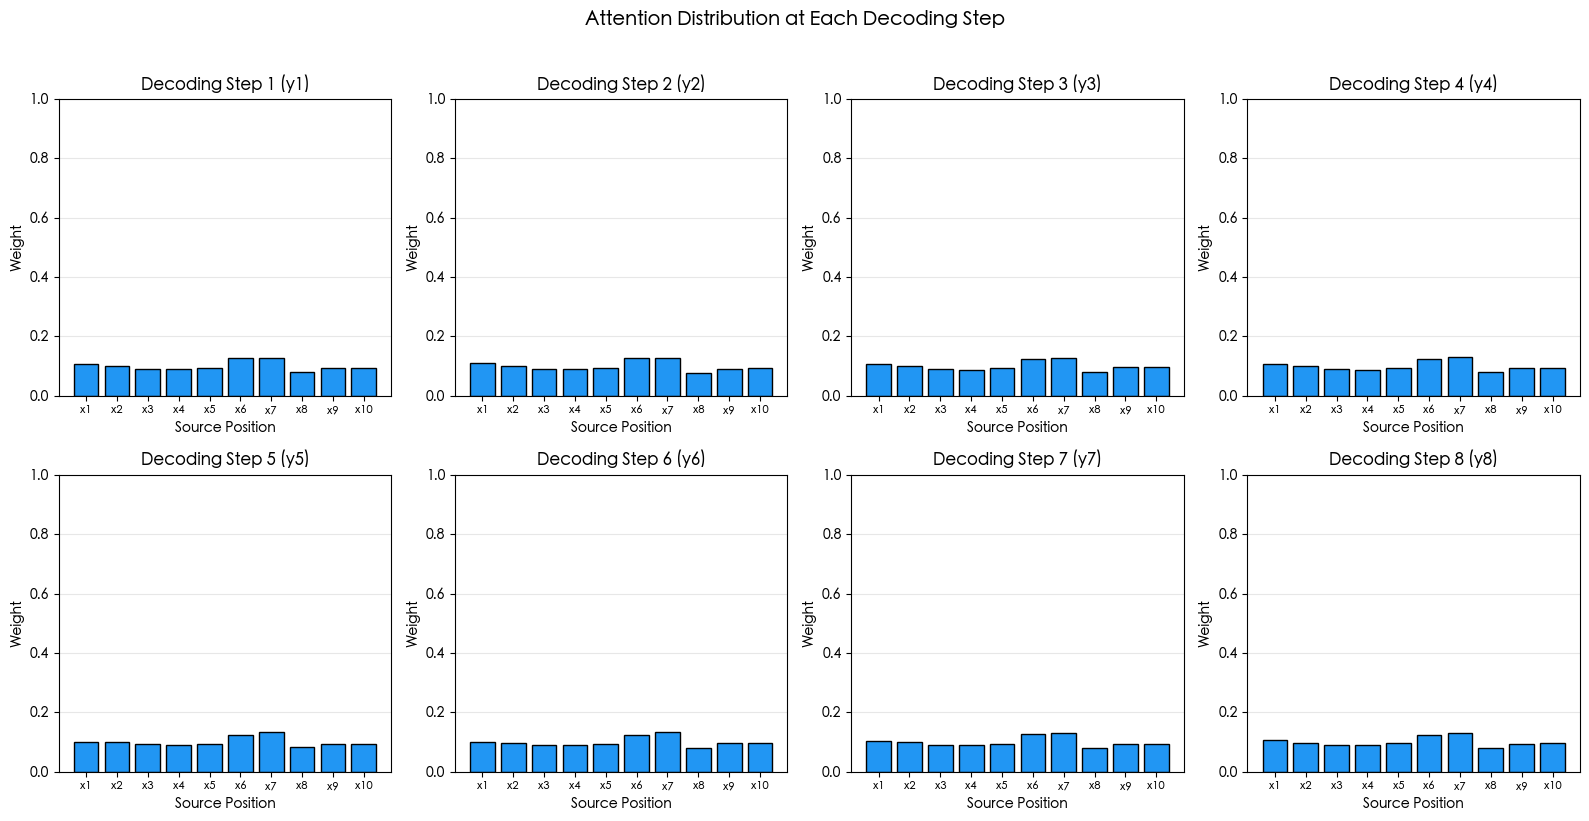

圖片已儲存：attention_per_step.png


In [8]:
# 視覺化每個解碼步驟的注意力分佈
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    if i < tgt_len:
        weights = attention_matrix[i]
        bars = ax.bar(range(src_len), weights, color='#2196F3', edgecolor='black')
        ax.set_title(f'Decoding Step {i+1} (y{i+1})')
        ax.set_xlabel('Source Position')
        ax.set_ylabel('Weight')
        ax.set_ylim(0, 1)
        ax.set_xticks(range(src_len))
        ax.set_xticklabels([f'x{j+1}' for j in range(src_len)], fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.axis('off')

plt.suptitle('Attention Distribution at Each Decoding Step', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_per_step.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：attention_per_step.png")

## 6. 完整 Seq2Seq 模型

In [9]:
class Seq2SeqWithAttention(nn.Module):
    """
    帶 Bahdanau 注意力的完整 Seq2Seq 模型
    """
    
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_size, hidden_size, dropout=0.1):
        super().__init__()
        
        # 編碼器（雙向，所以輸出維度是 2*hidden_size）
        self.encoder = BidirectionalEncoder(src_vocab_size, embed_size, hidden_size, dropout)
        
        # 解碼器（注意力維度是 2*hidden_size）
        annotation_size = 2 * hidden_size
        self.decoder = AttentionDecoder(tgt_vocab_size, embed_size, hidden_size, 
                                        annotation_size, dropout)
        
        # 初始化解碼器隱藏狀態的投影
        self.hidden_proj = nn.Linear(annotation_size, hidden_size)
    
    def forward(self, src, tgt=None, max_len=50):
        """
        Args:
            src: [batch, src_len] 來源序列
            tgt: [batch, tgt_len] 目標序列（訓練時）
            max_len: 最大生成長度（推論時）
        """
        # 編碼
        encoder_outputs, encoder_hidden = self.encoder(src)
        
        # 初始化解碼器隱藏狀態
        decoder_hidden = torch.tanh(self.hidden_proj(encoder_hidden))
        
        # 解碼
        if tgt is not None:
            outputs, attention_history = self.decoder(
                encoder_outputs, encoder_hidden, tgt
            )
        else:
            outputs, attention_history = self.decoder(
                encoder_outputs, encoder_hidden, max_len=max_len
            )
        
        return outputs, attention_history

# 測試完整模型
src_vocab_size = 5000
tgt_vocab_size = 5000
embed_size = 128
hidden_size = 64

model = Seq2SeqWithAttention(src_vocab_size, tgt_vocab_size, embed_size, hidden_size)

# 模擬翻譯
batch_size = 4
src_len = 15
tgt_len = 12

src = torch.randint(0, src_vocab_size, (batch_size, src_len))
tgt = torch.randint(0, tgt_vocab_size, (batch_size, tgt_len))

outputs, attention_history = model(src, tgt)

print("完整 Seq2Seq 模型測試：")
print(f"  來源序列形狀: {src.shape}")
print(f"  目標序列形狀: {tgt.shape}")
print(f"  輸出形狀: {outputs.shape}")
print(f"  注意力歷史形狀: {attention_history.shape}")

# 計算參數量
total_params = sum(p.numel() for p in model.parameters())
print(f"\n總參數量: {total_params:,}")

完整 Seq2Seq 模型測試：
  來源序列形狀: torch.Size([4, 15])
  目標序列形狀: torch.Size([4, 12])
  輸出形狀: torch.Size([4, 12, 5000])
  注意力歷史形狀: torch.Size([4, 12, 15])

總參數量: 3,041,928


## 7. 注意力類型比較

比較 Bahdanau（加性）和 Luong（乘性）注意力

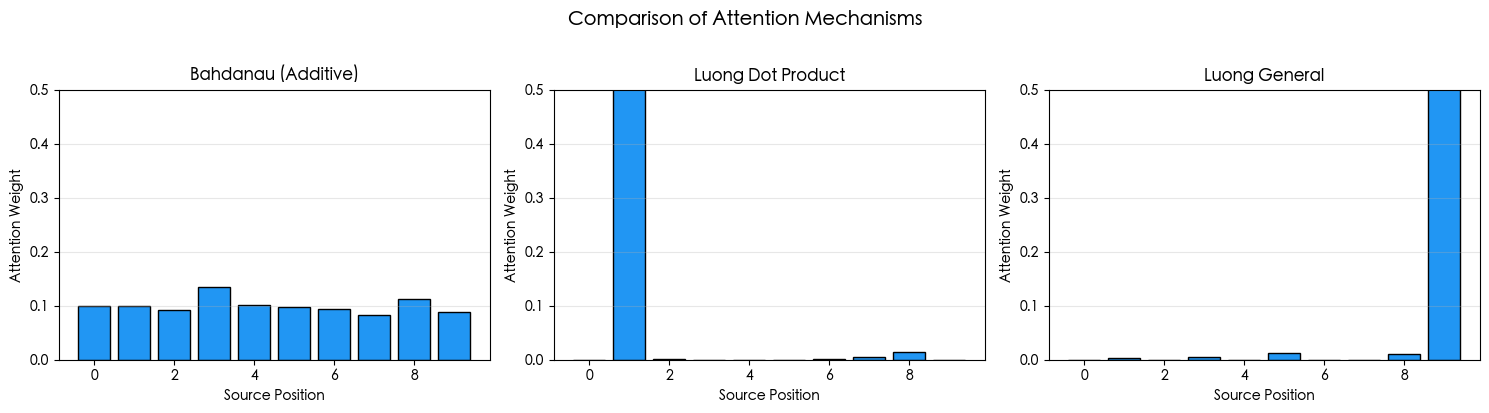

圖片已儲存：attention_comparison.png

注意力機制比較：
  Bahdanau: e = v^T tanh(Ws + Uh)  -- 加性，參數較多
  Luong Dot: e = s^T h  -- 點積，無額外參數
  Luong General: e = s^T W h  -- 帶權重矩陣


In [10]:
class LuongAttention(nn.Module):
    """
    Luong 乘性注意力（點積）
    
    e_ij = s^T h  或  e_ij = s^T W h
    """
    
    def __init__(self, hidden_size, annotation_size, method='dot'):
        """
        Args:
            hidden_size: 解碼器隱藏維度
            annotation_size: 編碼器註解維度
            method: 'dot'（點積）或 'general'（一般）
        """
        super().__init__()
        
        self.method = method
        
        if method == 'general':
            self.W = nn.Linear(annotation_size, hidden_size, bias=False)
    
    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        """
        Args:
            decoder_hidden: [batch, hidden_size]
            encoder_outputs: [batch, src_len, annotation_size]
        """
        if self.method == 'dot':
            # 點積：s^T h
            # 需要 hidden_size == annotation_size
            scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(-1)).squeeze(-1)
        else:
            # 一般：s^T W h
            transformed = self.W(encoder_outputs)  # [batch, src_len, hidden]
            scores = torch.bmm(transformed, decoder_hidden.unsqueeze(-1)).squeeze(-1)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        
        return context, attention_weights

# 比較兩種注意力的計算
hidden_size = 32
annotation_size = 32  # 點積需要相同維度
batch_size = 1
src_len = 10

bahdanau = BahdanauAttention(hidden_size, annotation_size)
luong_dot = LuongAttention(hidden_size, annotation_size, method='dot')
luong_general = LuongAttention(hidden_size, annotation_size, method='general')

decoder_hidden = torch.randn(batch_size, hidden_size)
encoder_outputs = torch.randn(batch_size, src_len, annotation_size)

_, w_bahdanau = bahdanau(decoder_hidden, encoder_outputs)
_, w_luong_dot = luong_dot(decoder_hidden, encoder_outputs)
_, w_luong_gen = luong_general(decoder_hidden, encoder_outputs)

# 視覺化比較
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

attention_types = [
    ('Bahdanau (Additive)', w_bahdanau[0].detach().numpy()),
    ('Luong Dot Product', w_luong_dot[0].detach().numpy()),
    ('Luong General', w_luong_gen[0].detach().numpy())
]

for ax, (name, weights) in zip(axes, attention_types):
    bars = ax.bar(range(src_len), weights, color='#2196F3', edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('Source Position')
    ax.set_ylabel('Attention Weight')
    ax.set_ylim(0, 0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparison of Attention Mechanisms', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：attention_comparison.png")
print("\n注意力機制比較：")
print("  Bahdanau: e = v^T tanh(Ws + Uh)  -- 加性，參數較多")
print("  Luong Dot: e = s^T h  -- 點積，無額外參數")
print("  Luong General: e = s^T W h  -- 帶權重矩陣")

## 8. 模擬翻譯任務：序列反轉

In [11]:
# 創建簡單的序列反轉任務
def create_reverse_data(num_samples, seq_len, vocab_size):
    """生成序列反轉的訓練資料"""
    # 來源序列（隨機）
    src = torch.randint(1, vocab_size, (num_samples, seq_len))  # 0 保留給 <PAD>
    # 目標序列（反轉）
    tgt = src.flip(dims=[1])
    return src, tgt

# 訓練設定
vocab_size = 20
seq_len = 8
embed_size = 32
hidden_size = 32
num_samples = 1000
batch_size = 32
num_epochs = 50

# 生成資料
src_data, tgt_data = create_reverse_data(num_samples, seq_len, vocab_size)

# 建立模型
model = Seq2SeqWithAttention(vocab_size, vocab_size, embed_size, hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(f"訓練序列反轉任務：")
print(f"  詞彙表大小: {vocab_size}")
print(f"  序列長度: {seq_len}")
print(f"  訓練樣本: {num_samples}")

訓練序列反轉任務：
  詞彙表大小: 20
  序列長度: 8
  訓練樣本: 1000


In [12]:
# 訓練迴圈
losses = []
accuracies = []

model.train()
for epoch in range(num_epochs):
    # 打亂資料
    perm = torch.randperm(num_samples)
    src_shuffled = src_data[perm]
    tgt_shuffled = tgt_data[perm]
    
    epoch_loss = 0
    correct = 0
    total = 0
    
    for i in range(0, num_samples, batch_size):
        src_batch = src_shuffled[i:i+batch_size]
        tgt_batch = tgt_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        
        outputs, _ = model(src_batch, tgt_batch)
        
        # 計算損失
        loss = criterion(outputs.view(-1, vocab_size), tgt_batch.view(-1))
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # 計算準確率
        predictions = outputs.argmax(dim=-1)
        correct += (predictions == tgt_batch).sum().item()
        total += tgt_batch.numel()
    
    avg_loss = epoch_loss / (num_samples // batch_size)
    accuracy = correct / total
    losses.append(avg_loss)
    accuracies.append(accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

print(f"\n最終準確率: {accuracies[-1]:.4f}")

Epoch 10/50, Loss: 1.3547, Accuracy: 0.5697
Epoch 20/50, Loss: 0.1940, Accuracy: 0.9627
Epoch 30/50, Loss: 0.0572, Accuracy: 0.9919
Epoch 40/50, Loss: 0.0245, Accuracy: 0.9965
Epoch 50/50, Loss: 0.0171, Accuracy: 0.9976

最終準確率: 0.9976


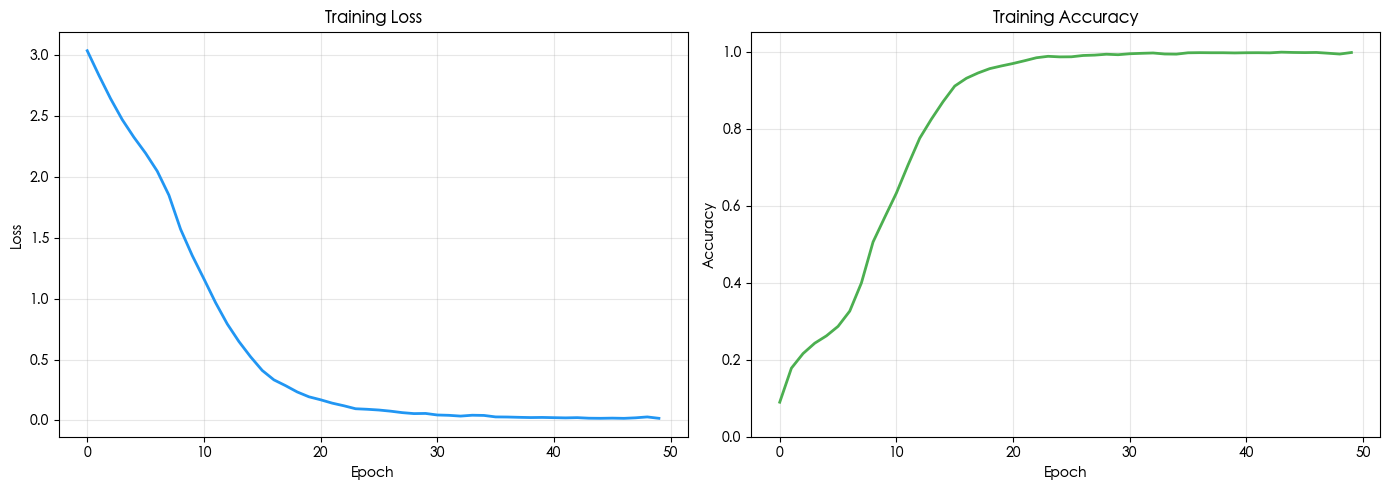

圖片已儲存：training_curves.png


In [13]:
# 視覺化訓練過程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(losses, color='#2196F3', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(accuracies, color='#4CAF50', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：training_curves.png")

In [14]:
# 測試並視覺化注意力
model.eval()

# 創建測試樣本
test_src = torch.tensor([[1, 2, 3, 4, 5, 6, 7, 8]])
test_tgt = test_src.flip(dims=[1])

with torch.no_grad():
    outputs, attention_history = model(test_src, test_tgt)

predictions = outputs.argmax(dim=-1)

print("測試結果：")
print(f"  輸入: {test_src[0].tolist()}")
print(f"  目標: {test_tgt[0].tolist()}")
print(f"  預測: {predictions[0].tolist()}")
print(f"  正確: {(predictions[0] == test_tgt[0]).all().item()}")

測試結果：
  輸入: [1, 2, 3, 4, 5, 6, 7, 8]
  目標: [8, 7, 6, 5, 4, 3, 2, 1]
  預測: [8, 7, 6, 5, 4, 3, 2, 1]
  正確: True


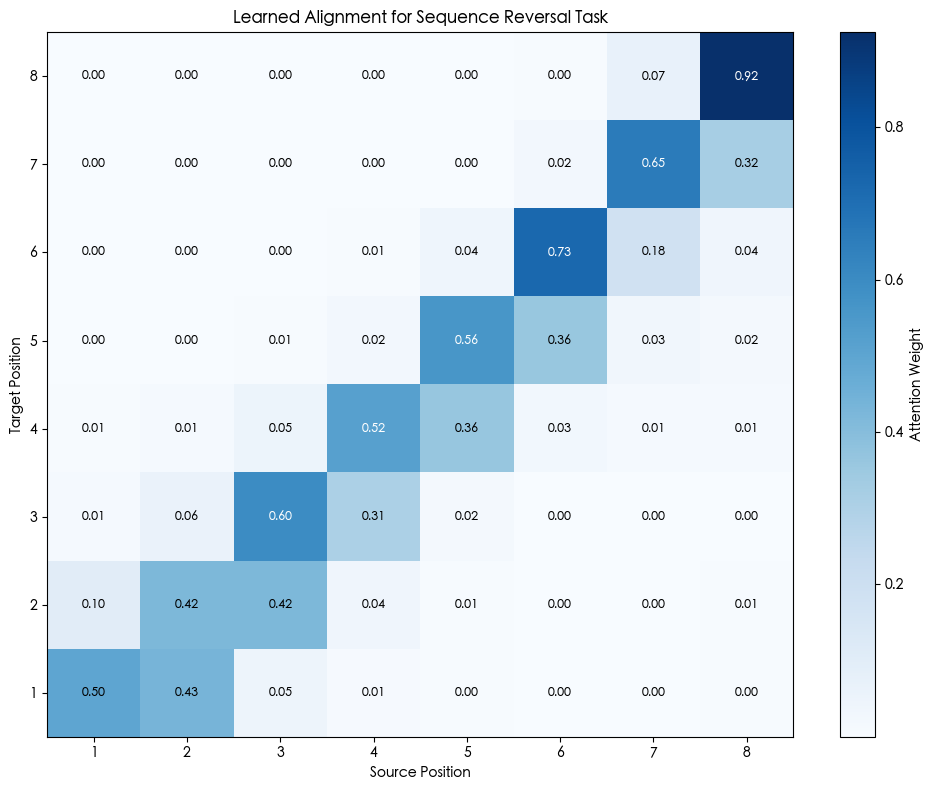

圖片已儲存：learned_alignment.png

對於序列反轉任務，理想的注意力應該是反對角線模式！
（第一個輸出對應最後一個輸入，以此類推）


In [15]:
# 視覺化學到的注意力對齊
attention_matrix = attention_history[0].detach().numpy()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')
plt.colorbar(im, label='Attention Weight')

ax.set_xlabel('Source Position')
ax.set_ylabel('Target Position')
ax.set_title('Learned Alignment for Sequence Reversal Task')

# 標籤
src_labels = [str(x) for x in test_src[0].tolist()]
tgt_labels = [str(x) for x in test_tgt[0].tolist()]

ax.set_xticks(range(seq_len))
ax.set_xticklabels(src_labels)
ax.set_yticks(range(seq_len))
ax.set_yticklabels(tgt_labels)

# 加入數值
for i in range(seq_len):
    for j in range(seq_len):
        val = attention_matrix[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.savefig('learned_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：learned_alignment.png")
print("\n對於序列反轉任務，理想的注意力應該是反對角線模式！")
print("（第一個輸出對應最後一個輸入，以此類推）")

## 總結

### Bahdanau 注意力的核心公式

1. **對齊分數**：$e_{ij} = v^T \tanh(W s_{i-1} + U h_j)$
2. **注意力權重**：$\alpha_{ij} = \text{softmax}(e_{ij})$
3. **上下文向量**：$c_i = \sum_j \alpha_{ij} h_j$

### 關鍵創新

1. **動態上下文**：每個解碼步驟有不同的上下文
2. **軟對齊**：自動學習來源和目標的對齊
3. **解決瓶頸**：不再將所有資訊壓縮到固定向量

### 歷史意義

- 這是注意力機制的開創性工作
- 為 Transformer 架構奠定了基礎
- 改變了序列模型的設計範式

In [16]:
print("="*60)
print("第十四章：Bahdanau 注意力機制 實作完成！")
print("="*60)
print("\n本章實作了：")
print("  1. Bahdanau 加性注意力機制")
print("  2. 雙向 GRU 編碼器")
print("  3. 帶注意力的 GRU 解碼器")
print("  4. 完整 Seq2Seq 模型")
print("  5. Luong 乘性注意力（比較）")
print("  6. 序列反轉任務訓練")
print("\n生成的圖片：")
print("  - attention_vs_fixed.png：固定向量 vs 注意力")
print("  - bahdanau_attention_weights.png：注意力權重分佈")
print("  - alignment_matrix.png：對齊矩陣")
print("  - attention_per_step.png：每步注意力分佈")
print("  - attention_comparison.png：注意力類型比較")
print("  - training_curves.png：訓練曲線")
print("  - learned_alignment.png：學到的對齊模式")

第十四章：Bahdanau 注意力機制 實作完成！

本章實作了：
  1. Bahdanau 加性注意力機制
  2. 雙向 GRU 編碼器
  3. 帶注意力的 GRU 解碼器
  4. 完整 Seq2Seq 模型
  5. Luong 乘性注意力（比較）
  6. 序列反轉任務訓練

生成的圖片：
  - attention_vs_fixed.png：固定向量 vs 注意力
  - bahdanau_attention_weights.png：注意力權重分佈
  - alignment_matrix.png：對齊矩陣
  - attention_per_step.png：每步注意力分佈
  - attention_comparison.png：注意力類型比較
  - training_curves.png：訓練曲線
  - learned_alignment.png：學到的對齊模式
